<a href="https://colab.research.google.com/github/borhan-m-uddin/data_mining/blob/main/SEDW_Full_Project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEDW: A Streaming Educational Data Warehouse with Drift-Aware Incremental Learning
## for Early Student Dropout Prediction

**Full Implementation Notebook**

---

### Project Structure
| Phase | Description |
|-------|-------------|
| 1 | Environment Setup & Dataset Download |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Streaming Simulation Layer |
| 4 | Streaming ETL Pipeline & Feature Engineering |
| 5 | Data Warehouse Schema (SQLite) |
| 6 | Concept Drift Detection (ADWIN) |
| 7 | Drift-Aware Incremental Learning Models |
| 8 | Batch Baseline Models (for comparison) |
| 9 | Prequential Evaluation Framework |
| 10 | Early Prediction Timeline Experiment |
| 11 | Behavioral Clustering |
| 12 | Sequential Pattern Mining |
| 13 | Temporal SHAP Explainability Analysis |
| 14 | DW OLAP Query Benchmarking |
| 15 | Results Visualization & Paper Figures |


---
## Phase 1 — Environment Setup & Dataset Download

In [2]:
from google.colab import drive
import os

mount_point = '/content/drive'
# Check if the mount point directory exists and contains files
if os.path.exists(mount_point) and os.listdir(mount_point):
    print(f'Mount point {mount_point} contains files. Attempting to unmount and remove contents.')
    # Try to unmount first
    try:
        drive.flush_and_unmount()
    except Exception:
        pass # Ignore if unmount fails, proceed with rmdir
    # Remove the directory and its contents
    os.system(f'sudo rm -rf {mount_point}')
    # Recreate the empty directory
    os.makedirs(mount_point, exist_ok=True)

drive.mount(mount_point, force_remount=True)

Mounted at /content/drive


In [3]:
# ============================================================
# CELL 1.1 — Install Dependencies
# Run this cell first, then restart runtime if using Colab
# ============================================================
!pip install river -q
!pip install scikit-learn xgboost lightgbm imbalanced-learn -q
!pip install matplotlib seaborn plotly shap -q
!pip install prefixspan -q
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 89.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
river 0.24.2 requires numpy<3,>=2.3.4, but you have numpy 2.0.2 which is incompatible.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
All packages installed.


In [4]:
# ============================================================
# CELL 1.2 — Import All Libraries
# ============================================================
import os
import sqlite3
import warnings
import time
import json
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    roc_auc_score, cohen_kappa_score, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb

# River — Streaming ML
from river import (
    tree, ensemble, drift, metrics, stream,
    preprocessing, evaluate, linear_model, naive_bayes, forest
)
from river.drift import ADWIN
from river.tree import HoeffdingTreeClassifier
from river.forest import ARFClassifier
from river.ensemble import BaggingClassifier
from river.metrics import Accuracy, CohenKappa, F1, ClassificationReport

# SHAP
import shap

# Sequential Pattern Mining
from prefixspan import PrefixSpan

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directory
OUTPUT_DIR = Path('/content/drive/MyDrive/SEDW_Project/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ All libraries imported successfully.')
print(f'📁 Outputs will be saved to: {OUTPUT_DIR.resolve()}')

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x786a0ef0efc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


✅ All libraries imported successfully.
📁 Outputs will be saved to: /content/drive/MyDrive/SEDW_Project/outputs


In [5]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 150

In [6]:
# ============================================================
# CELL 1.3 — Dataset Download
# Download the Streaming Learning Analytics Dataset from Zenodo
# DOI: 10.5281/zenodo.14003233
# ============================================================

# --- OPTION A: Download from Zenodo (Google Colab / online) ---
# Uncomment the lines below if running in Colab
# !wget -q https://zenodo.org/records/14003233/files/streaming_learning_analytics.csv \
#        -O streaming_dataset.csv
# print('✅ Dataset downloaded from Zenodo.')

# --- OPTION B: Upload manually ---
# If running locally, place the CSV file in the same folder as this notebook
# and set the path below.
DATASET_PATH = '/content/drive/MyDrive/SEDW_Project/dataset4classes.csv'  # <-- update path if needed

# --- OPTION C: Generate synthetic dataset (for testing pipeline) ---
# This mirrors the structure of the real dataset.
# Remove this block once you have the real dataset.

def generate_synthetic_dataset(n_students=2000, seed=42):
    """Generate a synthetic dataset matching Streaming Learning Analytics
    dataset structure for pipeline testing."""
    np.random.seed(seed)
    n = n_students
    student_ids = np.repeat(np.arange(1, n + 1), 30)  # 30 weeks per student
    weeks = np.tile(np.arange(1, 31), n)

    genders      = np.repeat(np.random.choice(['M','F'], n), 30)
    regions      = np.repeat(np.random.choice(['London','North','South','Midlands','Scotland'], n), 30)
    education    = np.repeat(np.random.choice(['A Level or Equivalent','HE Qualification',
                                               'Lower Than A Level','No Formal quals'], n), 30)
    age_band     = np.repeat(np.random.choice(['0-35','35-55','55<='], n), 30)
    disability   = np.repeat(np.random.choice(['Y','N'], n, p=[0.1, 0.9]), 30)
    imd_band     = np.repeat(np.random.choice(['0-10%','10-20','20-30%','30-40%',
                                               '40-50%','50-60%','60-70%','70-80%',
                                               '80-90%','90-100%'], n), 30)
    prev_attempts= np.repeat(np.random.choice([0,1,2,3], n, p=[0.6,0.25,0.1,0.05]), 30)
    module_codes = np.repeat(np.random.choice(['AAA','BBB','CCC','DDD','EEE'], n), 30)

    activity_types = np.random.choice(
        ['forumng','resource','oucontent','url','quiz','homepage','subpage','ouwiki'],
        len(student_ids)
    )
    clicks = np.random.poisson(lam=15, size=len(student_ids))

    # Simulate assessment scores (not every week)
    has_assessment = (weeks % 5 == 0).astype(int)
    scores = np.where(has_assessment, np.random.normal(55, 20, len(weeks)).clip(0, 100), np.nan)

    # Assign final outcomes — correlated with activity
    student_activity_mean = np.repeat(
        np.random.normal(15, 8, n).clip(0, None), 30
    )
    outcome_prob = np.clip(student_activity_mean / 40, 0, 1)
    base_outcomes = np.random.choice(
        ['Pass','Fail','Withdrawn','Distinction'], n,
        p=[0.40, 0.25, 0.25, 0.10]
    )
    final_result = np.repeat(base_outcomes, 30)

    df = pd.DataFrame({
        'id_student':         student_ids,
        'week':               weeks,
        'code_module':        module_codes,
        'gender':             genders,
        'region':             regions,
        'highest_education':  education,
        'age_band':           age_band,
        'disability':         disability,
        'imd_band':           imd_band,
        'num_prev_attempts':  prev_attempts,
        'activity_type':      activity_types,
        'sum_click':          clicks,
        'score':              scores,
        'final_result':       final_result
    })
    return df

if not os.path.exists(DATASET_PATH):
    print('⚠️  Dataset file not found. Generating synthetic dataset for testing...')
    df_raw = generate_synthetic_dataset(n_students=2000)
    df_raw.to_csv(DATASET_PATH, index=False)
    print(f'✅ Synthetic dataset saved: {DATASET_PATH}')
    print(f'   Shape: {df_raw.shape}')
    print('   NOTE: Replace with real Zenodo dataset for actual research.')
else:
    df_raw = pd.read_csv(DATASET_PATH)
    print(f'✅ Dataset loaded: {DATASET_PATH}')
    print(f'   Shape: {df_raw.shape}')

df_raw.head()

✅ Dataset loaded: /content/drive/MyDrive/SEDW_Project/dataset4classes.csv
   Shape: (1718983, 34)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date,dataplus,dualpane,externalquiz,folder,forumng,glossary,homepage,htmlactivity,oucollaborate,oucontent,ouelluminate,ouwiki,page,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url,score,final_result
0,0.0000,1.0000,11391,0.0000,0.0000,3.0000,9.0000,2.0000,0,240,0.0000,237,0,0,0,0,2,0,7,0,0,78,0,0,0,0,0,0,0,0,11,0,NaN,2.0000
1,0.0000,1.0000,11391,0.0000,0.0000,3.0000,9.0000,2.0000,0,240,0.0000,242,0,0,0,0,15,0,10,0,0,21,0,0,0,0,0,0,3,0,0,0,NaN,2.0000
2,0.0000,1.0000,11391,0.0000,0.0000,3.0000,9.0000,2.0000,0,240,0.0000,243,0,0,0,0,3,0,9,0,0,102,0,0,0,0,0,0,4,0,8,1,NaN,2.0000
3,0.0000,1.0000,11391,0.0000,0.0000,3.0000,9.0000,2.0000,0,240,0.0000,244,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,1,0,0,0,NaN,2.0000
4,0.0000,1.0000,11391,0.0000,0.0000,3.0000,9.0000,2.0000,0,240,0.0000,248,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,NaN,2.0000


---
## Phase 2 — Exploratory Data Analysis (EDA)

In [7]:
# ============================================================
# CELL 2.1 — Basic Dataset Statistics
# ============================================================
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total Records      : {len(df_raw):,}')
print(f'Unique Students    : {df_raw["id_student"].nunique():,}')
print(f'Features           : {df_raw.shape[1]}')
print(f'Missing Values     : {df_raw.isnull().sum().sum():,}')
print()
print('--- Column Info ---')
print(df_raw.dtypes)
print()
print('--- Class Distribution ---')
class_counts = df_raw.groupby('id_student')['final_result'].first().value_counts()
print(class_counts)
print()
class_pct = (class_counts / class_counts.sum() * 100).round(2)
print('Percentages:')
print(class_pct)

DATASET OVERVIEW
Total Records      : 1,718,983
Unique Students    : 25,149
Features           : 34
Missing Values     : 1,603,391

--- Column Info ---
code_module             float64
code_presentation       float64
id_student                int64
gender                  float64
region                  float64
highest_education       float64
imd_band                float64
age_band                float64
num_of_prev_attempts      int64
studied_credits           int64
disability              float64
date                      int64
dataplus                  int64
dualpane                  int64
externalquiz              int64
folder                    int64
forumng                   int64
glossary                  int64
homepage                  int64
htmlactivity              int64
oucollaborate             int64
oucontent                 int64
ouelluminate              int64
ouwiki                    int64
page                      int64
questionnaire             int64
quiz            

In [9]:
df_raw.head()
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1718983 entries, 0 to 1718982
Data columns (total 34 columns):
 #   Column                Dtype  
---  ------                -----  
 0   code_module           float64
 1   code_presentation     float64
 2   id_student            int64  
 3   gender                float64
 4   region                float64
 5   highest_education     float64
 6   imd_band              float64
 7   age_band              float64
 8   num_of_prev_attempts  int64  
 9   studied_credits       int64  
 10  disability            float64
 11  date                  int64  
 12  dataplus              int64  
 13  dualpane              int64  
 14  externalquiz          int64  
 15  folder                int64  
 16  forumng               int64  
 17  glossary              int64  
 18  homepage              int64  
 19  htmlactivity          int64  
 20  oucollaborate         int64  
 21  oucontent             int64  
 22  ouelluminate          int64  
 23  ouwiki 

MISSING VALUE ANALYSIS
       Missing Count  Missing Percentage
score        1603391             93.2756


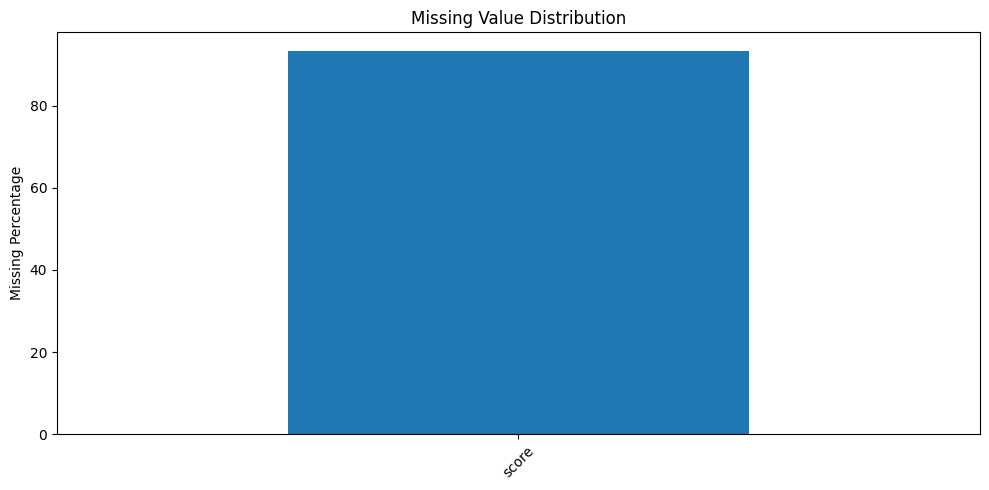

In [12]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

missing_values = df_raw.isnull().sum()
missing_percent = (missing_values / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by='Missing Percentage', ascending=False)

print(missing_df)

# Optional Visualization
plt.figure(figsize=(10,5))
missing_df['Missing Percentage'].plot(kind='bar')
plt.ylabel("Missing Percentage")
plt.title("Missing Value Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Filling numeric missing values with median
for col in df_raw.select_dtypes(include=['float64', 'int64']).columns:
    df_raw[col] = df_raw[col].fillna(df_raw[col].median())

# Filling categorical missing values with mode
for col in df_raw.select_dtypes(include=['object']).columns:
    if not df_raw[col].mode().empty:
        df_raw[col] = df_raw[col].fillna(df_raw[col].mode()[0])

print("Missing values handled successfully in df_raw.")

Missing values handled successfully in df_raw.


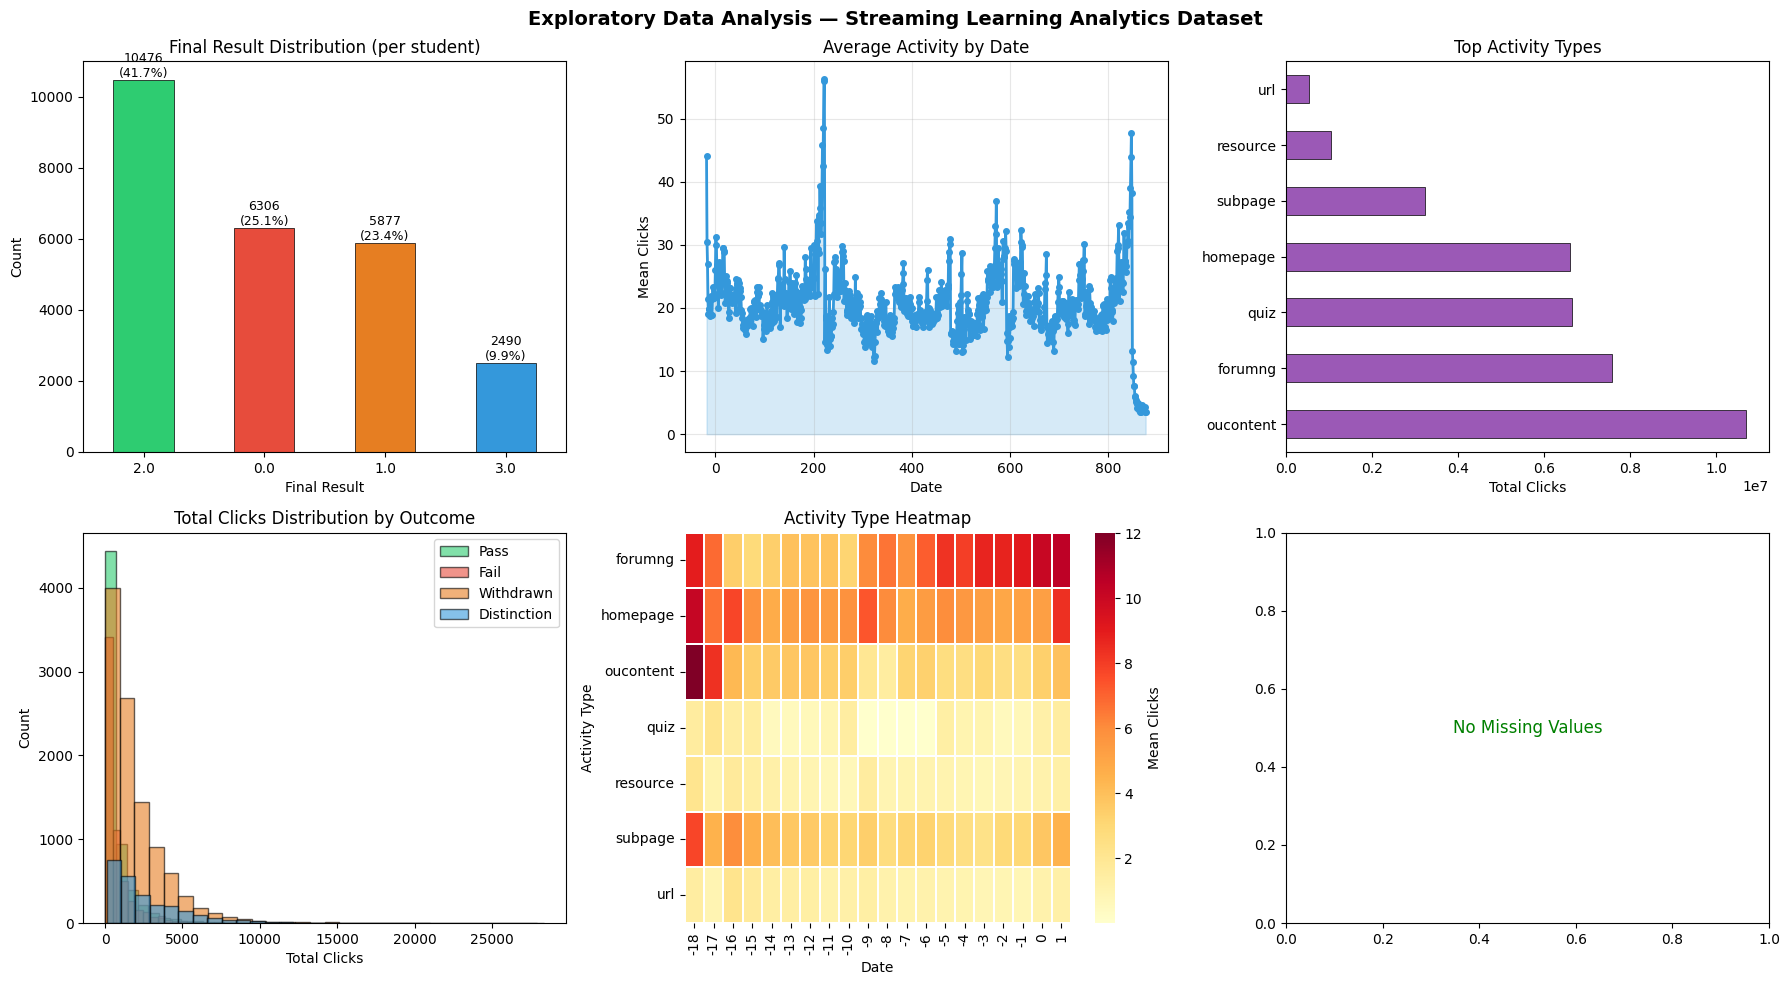

✅ EDA figure saved.


In [15]:
# ============================================================
# CELL 2.2 — EDA Visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — Streaming Learning Analytics Dataset',
             fontsize=14, fontweight='bold')

# Map internal column 'date' to 'week' logic if necessary
time_col = 'date' if 'date' in df_raw.columns else 'week'

# 1. Class distribution
ax = axes[0, 0]
colors = ['#2ecc71','#e74c3c','#e67e22','#3498db']
class_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Final Result Distribution (per student)')
ax.set_xlabel('Final Result')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/class_counts.sum()*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

# Identify activity columns (columns between disability and score)
activity_cols = ['forumng', 'homepage', 'oucontent', 'quiz', 'resource', 'subpage', 'url']
activity_cols = [c for c in activity_cols if c in df_raw.columns]
df_raw['total_clicks_row'] = df_raw[activity_cols].sum(axis=1)

# 2. Activity volume over time
ax = axes[0, 1]
trend_data = df_raw.groupby(time_col)['total_clicks_row'].mean()
ax.plot(trend_data.index, trend_data.values, marker='o', color='#3498db', linewidth=2, markersize=4)
ax.fill_between(trend_data.index, trend_data.values, alpha=0.2, color='#3498db')
ax.set_title(f'Average Activity by {time_col.capitalize()}')
ax.set_xlabel(time_col.capitalize())
ax.set_ylabel('Mean Clicks')
ax.grid(True, alpha=0.3)

# 3. Activity type distribution
ax = axes[0, 2]
if activity_cols:
    act_sum = df_raw[activity_cols].sum().sort_values(ascending=False).head(8)
    act_sum.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.set_title('Top Activity Types')
ax.set_xlabel('Total Clicks')

# 4. Clicks distribution by final result
ax = axes[1, 0]
student_stats = df_raw.groupby('id_student').agg(
    total_clicks=('total_clicks_row','sum'),
    final_result=('final_result','first')
).reset_index()
# Map results if they are numeric (0,1,2,3)
res_map = {0.0: 'Pass', 1.0: 'Fail', 2.0: 'Withdrawn', 3.0: 'Distinction'}
for i, (val, label) in enumerate(res_map.items()):
    data = student_stats[student_stats['final_result'] == val]['total_clicks']
    if len(data) > 0:
        ax.hist(data, bins=30, alpha=0.6, color=colors[i % len(colors)], label=label, edgecolor='black', lw=0.3)
ax.set_title('Total Clicks Distribution by Outcome')
ax.set_xlabel('Total Clicks')
ax.set_ylabel('Count')
ax.legend()

# 5. Heatmap: time vs activity type
ax = axes[1, 1]
if time_col in df_raw.columns and activity_cols:
    pivot = df_raw.groupby(time_col)[activity_cols].mean()
    sns.heatmap(pivot.T.iloc[:, :20], ax=ax, cmap='YlOrRd', linewidths=0.1, cbar_kws={'label': 'Mean Clicks'})
    ax.set_title('Activity Type Heatmap')
    ax.set_xlabel(time_col.capitalize())
    ax.set_ylabel('Activity Type')

# 6. Missing values
ax = axes[1, 2]
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    missing.plot(kind='bar', ax=ax, color='#e74c3c')
    ax.set_title('Missing Values per Column')
    ax.set_ylabel('Count')
else:
    ax.text(0.5, 0.5, 'No Missing Values',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='green')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA figure saved.')

---
## Phase 3 — Streaming Simulation Layer

In [16]:
# ============================================================
# CELL 3.1 — Build Week-Ordered Stream
# Converts the static CSV into a temporally ordered stream
# ============================================================

def build_stream(df):
    """Sort data by temporal column → student to simulate stream arrival.
    Renames 'date' to 'week' for pipeline compatibility."""
    # Determine the time column (it is 'date' in this dataset)
    time_col = 'date' if 'date' in df.columns else 'week'

    df_sorted = df.sort_values([time_col, 'id_student']).reset_index(drop=True)

    # Rename to 'week' to satisfy the rest of the project pipeline
    if time_col == 'date':
        df_sorted = df_sorted.rename(columns={'date': 'week'})

    return df_sorted

df_stream = build_stream(df_raw)

print('Stream Construction Complete')
print(f'  Total stream records : {len(df_stream):,}')
print(f'  Weeks covered        : {df_stream["week"].min()} → {df_stream["week"].max()}')
print(f'  Records per week     : ~{len(df_stream)//df_stream["week"].nunique():,}')
print()
print('First 5 stream records:')
df_stream.head()

Stream Construction Complete
  Total stream records : 1,718,983
  Weeks covered        : -18 → 876
  Records per week     : ~1,920

First 5 stream records:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,week,dataplus,dualpane,externalquiz,folder,forumng,glossary,homepage,htmlactivity,oucollaborate,oucontent,ouelluminate,ouwiki,page,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url,score,final_result,total_clicks_row
0,5.0000,0.0000,35544,0.0000,5.0000,2.0000,8.0000,1.0000,0,60,0.0000,-18,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,79.0000,2.0000,1
1,5.0000,0.0000,35860,0.0000,7.0000,2.0000,1.0000,0.0000,0,60,0.0000,-18,0,0,0,0,9,0,5,0,0,5,0,0,0,0,0,0,2,0,4,1,79.0000,2.0000,26
2,5.0000,0.0000,42668,0.0000,10.0000,1.0000,1.0000,1.0000,1,120,0.0000,-18,0,0,0,0,26,0,6,0,0,0,0,0,1,0,0,0,0,0,0,0,79.0000,2.0000,32
3,5.0000,0.0000,43430,0.0000,7.0000,2.0000,5.0000,1.0000,0,60,0.0000,-18,0,0,0,0,4,0,4,0,0,20,0,1,3,0,3,0,4,0,17,2,79.0000,2.0000,54
4,5.0000,0.0000,50263,0.0000,4.0000,3.0000,8.0000,1.0000,0,60,0.0000,-18,0,0,0,0,18,0,18,0,0,0,0,0,2,0,1,0,0,0,2,2,79.0000,2.0000,41


In [17]:
# ============================================================
# CELL 3.2 — Stream Emitter (Generator Function)
# Emits one week's batch at a time — simulates real-time arrival
# ============================================================

def stream_emitter(df, week_col='week'):
    """Generator: yields one weekly batch at a time."""
    for week_num in sorted(df[week_col].unique()):
        batch = df[df[week_col] == week_num].copy()
        yield week_num, batch

# Test the emitter
print('Stream emitter test:')
emitter = stream_emitter(df_stream)
for i in range(3):
    week_num, batch = next(emitter)
    print(f'  Week {week_num:2d}: {len(batch):5,} records')
print('  ...')
print('✅ Stream emitter working correctly.')

Stream emitter test:
  Week -18:   588 records
  Week -17:   448 records
  Week -16:   700 records
  ...
✅ Stream emitter working correctly.


---
## Phase 4 — Streaming ETL Pipeline & Feature Engineering

In [18]:
# ============================================================
# CELL 4.1 — Activity Weight Dictionary
# ============================================================

ACTIVITY_WEIGHTS = {
    'forumng':   3.0,   # highest — collaborative engagement
    'ouwiki':    2.8,
    'quiz':      2.5,   # assessment-related
    'assignment':2.5,
    'subpage':   1.8,
    'oucontent': 1.5,
    'resource':  1.3,
    'url':       1.2,
    'homepage':  1.0,   # passive navigation
    'ouelluminate':1.8,
    'dataplus':  1.5,
    'glossary':  1.3,
}
DEFAULT_WEIGHT = 1.0

print('Activity weights defined:', ACTIVITY_WEIGHTS)

Activity weights defined: {'forumng': 3.0, 'ouwiki': 2.8, 'quiz': 2.5, 'assignment': 2.5, 'subpage': 1.8, 'oucontent': 1.5, 'resource': 1.3, 'url': 1.2, 'homepage': 1.0, 'ouelluminate': 1.8, 'dataplus': 1.5, 'glossary': 1.3}


In [19]:
# ============================================================
# CELL 4.2 — Feature Engineering Engine
# Computes behavioral features per student per week
# ============================================================

class StudentFeatureStore:
    """Maintains rolling state for each student across weeks."""

    def __init__(self):
        # engagement_history[student_id] = list of weekly engagement scores
        self.engagement_history = {}
        # activity_counts[student_id] = list of weekly activity volumes
        self.activity_counts    = {}
        # score_history[student_id]  = list of assessment scores
        self.score_history      = {}
        # submission_delays (approximated)
        self.delay_history      = {}
        # week counter
        self.weeks_seen         = {}

    def update(self, student_id, week, activity_type, sum_click, score):
        """Update state for a student with one interaction record."""
        w = ACTIVITY_WEIGHTS.get(str(activity_type).lower(), DEFAULT_WEIGHT)
        engagement_contrib = w * sum_click

        if student_id not in self.engagement_history:
            self.engagement_history[student_id] = []
            self.activity_counts[student_id]    = []
            self.score_history[student_id]      = []
            self.delay_history[student_id]      = []
            self.weeks_seen[student_id]         = set()

        # Aggregate within week — sum engagements
        if week not in self.weeks_seen[student_id]:
            self.engagement_history[student_id].append(engagement_contrib)
            self.activity_counts[student_id].append(sum_click)
            if not np.isnan(score):
                self.score_history[student_id].append(score)
            self.weeks_seen[student_id].add(week)
        else:
            # Accumulate within same week
            self.engagement_history[student_id][-1] += engagement_contrib
            self.activity_counts[student_id][-1]    += sum_click

    def get_features(self, student_id):
        """Compute behavioral features from current state."""
        eng  = self.engagement_history.get(student_id, [0])
        acts = self.activity_counts.get(student_id, [0])
        scrs = self.score_history.get(student_id, [])

        eng_arr  = np.array(eng,  dtype=float)
        acts_arr = np.array(acts, dtype=float)

        # Feature 1: Current engagement score (last week, normalized)
        engagement_score = float(eng_arr[-1]) if len(eng_arr) > 0 else 0.0

        # Feature 2: Weekly activity volume (last week)
        weekly_volume = float(acts_arr[-1]) if len(acts_arr) > 0 else 0.0

        # Feature 3: Learning consistency (std of activity over last 4 weeks)
        consistency = float(np.std(acts_arr[-4:])) if len(acts_arr) >= 2 else 0.0

        # Feature 4: Cumulative engagement trend (slope over last 3 weeks)
        if len(eng_arr) >= 3:
            x = np.arange(len(eng_arr[-3:]))
            trend = float(np.polyfit(x, eng_arr[-3:], 1)[0])
        else:
            trend = 0.0

        # Feature 5: Relative activity drop (vs personal mean)
        personal_mean = float(np.mean(acts_arr)) if len(acts_arr) > 0 else 1.0
        if personal_mean > 0 and len(acts_arr) >= 2:
            relative_drop = float((personal_mean - acts_arr[-1]) / personal_mean)
        else:
            relative_drop = 0.0

        # Feature 6: Assessment momentum (running avg of last 3 scores)
        if len(scrs) >= 1:
            assessment_momentum = float(np.mean(scrs[-3:]))
        else:
            assessment_momentum = 50.0  # neutral default

        # Feature 7: Cumulative total engagement
        cumulative_engagement = float(np.sum(eng_arr))

        # Feature 8: Total weeks active
        weeks_active = len(self.weeks_seen.get(student_id, set()))

        # Feature 9: Risk score (composite — higher = more at risk)
        risk_score = (
            0.35 * max(0, -trend / (abs(engagement_score) + 1)) +
            0.30 * max(0, relative_drop) +
            0.20 * (consistency / (weekly_volume + 1)) +
            0.15 * max(0, (50 - assessment_momentum) / 50)
        )
        risk_score = float(np.clip(risk_score * 100, 0, 100))

        return {
            'engagement_score':     engagement_score,
            'weekly_volume':        weekly_volume,
            'learning_consistency': consistency,
            'cumulative_trend':     trend,
            'relative_drop':        relative_drop,
            'assessment_momentum':  assessment_momentum,
            'cumulative_engagement':cumulative_engagement,
            'weeks_active':         weeks_active,
            'risk_score':           risk_score
        }


print('✅ StudentFeatureStore class defined.')

✅ StudentFeatureStore class defined.


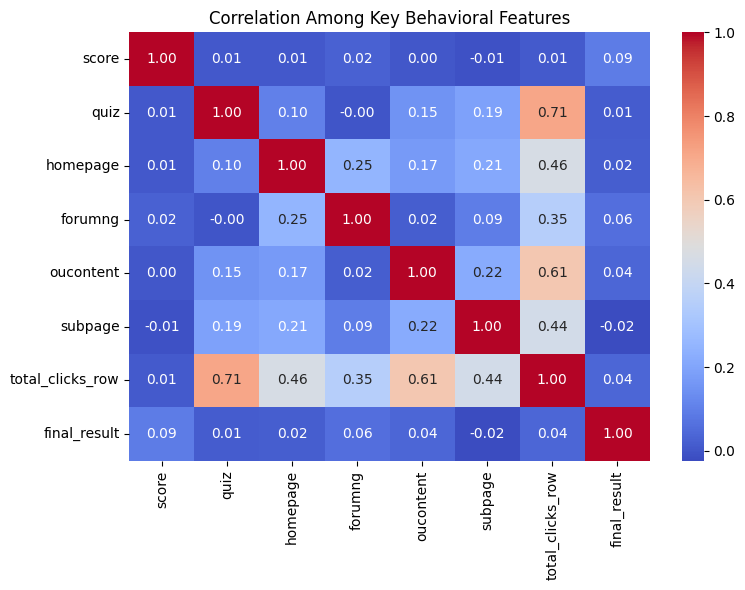

In [23]:
# ============================================================
# IMPROVED CORRELATION HEATMAP
# ============================================================

selected_features = [
    'score',
    'quiz',
    'homepage',
    'forumng',
    'oucontent',
    'subpage',
    'total_clicks_row',
    'final_result'
]

corr_matrix = df_raw[selected_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Among Key Behavioral Features")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 4.3 — Run Full ETL Pipeline
# Process all weeks, extract features, build enriched dataset
# ============================================================
import pickle

def save_checkpoint(obj, name):
    """Save an object to the output directory."""
    path = OUTPUT_DIR / f"{name}.pkl"
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Checkpoint saved: {name}")

def load_checkpoint(name):
    """Load an object from the output directory."""
    path = OUTPUT_DIR / f"{name}.pkl"
    if path.exists():
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

# Label encoding for target
CLASS_MAP = {'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3}
CLASS_NAMES = {v: k for k, v in CLASS_MAP.items()}

# Demographic encoding
def encode_demographics(df):
    """One-hot encode categorical demographic columns."""
    cat_cols = ['gender', 'region', 'highest_education', 'age_band',
                'disability', 'imd_band', 'code_module']
    cat_cols = [c for c in cat_cols if c in df.columns]
    return pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print('Running ETL pipeline...')
store = StudentFeatureStore()
etl_records = []

for week_num, batch in stream_emitter(df_stream):
    for _, row in batch.iterrows():
        sid   = row['id_student']
        score = row['score'] if 'score' in row and not pd.isna(row['score']) else np.nan
        atype = row.get('activity_type', 'resource')
        click = row.get('sum_click', 0)

        store.update(sid, week_num, atype, click, score)
        feats = store.get_features(sid)

        record = {
            'id_student':        sid,
            'week':              week_num,
            'code_module':       row.get('code_module', 'UNK'),
            'gender':            row.get('gender', 'M'),
            'region':            row.get('region', 'Unknown'),
            'highest_education': row.get('highest_education', 'Unknown'),
            'age_band':          row.get('age_band', '0-35'),
            'disability':        row.get('disability', 'N'),
            'imd_band':          row.get('imd_band', '50-60%'),
            'num_prev_attempts': int(row.get('num_prev_attempts', 0)),
            'final_result':      row.get('final_result', 'Pass'),
            **feats
        }
        etl_records.append(record)

df_etl = pd.DataFrame(etl_records)
save_checkpoint(df_etl, 'df_etl')

# Encode target
df_etl['target'] = df_etl['final_result'].map(CLASS_MAP).fillna(0).astype(int)

# Risk band dimension
def risk_band(score):
    if score < 30:   return 'Low'
    elif score < 60: return 'Moderate'
    elif score < 85: return 'High'
    else:            return 'Critical'

df_etl['risk_band'] = df_etl['risk_score'].apply(risk_band)

print(f'✅ ETL complete. Enriched dataset shape: {df_etl.shape}')
print(f'   Behavioral features per record: 9')
print()
df_etl.head(3)

Running ETL pipeline...
✅ Checkpoint saved: df_etl
✅ ETL complete. Enriched dataset shape: (1718983, 22)
   Behavioral features per record: 9



,id_student,week,code_module,gender,region,highest_education,age_band,disability,imd_band,num_prev_attempts,final_result,engagement_score,weekly_volume,learning_consistency,cumulative_trend,relative_drop,assessment_momentum,cumulative_engagement,weeks_active,risk_score,target,risk_band
0,35544.0000,-18,5.0000,0.0000,5.0000,2.0000,1.0000,0.0000,8.0000,0,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,79.0000,0.0000,1,0.0000,0,Low
1,35860.0000,-18,5.0000,0.0000,7.0000,2.0000,0.0000,0.0000,1.0000,0,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,79.0000,0.0000,1,0.0000,0,Low
2,42668.0000,-18,5.0000,0.0000,10.0000,1.0000,1.0000,0.0000,1.0000,0,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,79.0000,0.0000,1,0.0000,0,Low


---
## Phase 5 — Data Warehouse Schema (SQLite)

In [25]:
# ============================================================
# CELL 5.1 — Create Temporal Star Schema in SQLite
# Tables: FACT_STREAM_ACTIVITY, FACT_BEHAVIORAL_DRIFT,
#         DIM_STUDENT, DIM_COURSE, DIM_TIME,
#         DIM_ACTIVITY, DIM_RISK_BAND
# ============================================================

DW_PATH = OUTPUT_DIR / 'SEDW_warehouse.db'
conn = sqlite3.connect(str(DW_PATH))
cursor = conn.cursor()

# Drop existing tables for clean rebuild
tables = ['FACT_STREAM_ACTIVITY','FACT_BEHAVIORAL_DRIFT',
          'DIM_STUDENT','DIM_COURSE','DIM_TIME',
          'DIM_ACTIVITY','DIM_RISK_BAND']
for t in tables:
    cursor.execute(f'DROP TABLE IF EXISTS {t}')

# --- DIMENSION: DIM_STUDENT ---
cursor.execute('''
CREATE TABLE DIM_STUDENT (
    Student_ID       INTEGER PRIMARY KEY,
    Gender           TEXT,
    Region           TEXT,
    Highest_Education TEXT,
    Age_Band         TEXT,
    Disability       TEXT,
    IMD_Band         TEXT,
    Num_Prev_Attempts INTEGER
)
''')

# --- DIMENSION: DIM_COURSE ---
cursor.execute('''
CREATE TABLE DIM_COURSE (
    Course_ID   INTEGER PRIMARY KEY AUTOINCREMENT,
    Module_Code TEXT UNIQUE,
    Presentation TEXT,
    Module_Level TEXT
)
''')

# --- DIMENSION: DIM_TIME ---
cursor.execute('''
CREATE TABLE DIM_TIME (
    Time_ID         INTEGER PRIMARY KEY,
    Week_Number     INTEGER,
    Month           INTEGER,
    Semester_Phase  TEXT,
    Days_Until_Exam INTEGER
)
''')

# --- DIMENSION: DIM_ACTIVITY ---
cursor.execute('''
CREATE TABLE DIM_ACTIVITY (
    Activity_ID           INTEGER PRIMARY KEY AUTOINCREMENT,
    Activity_Type         TEXT UNIQUE,
    Activity_Weight       REAL,
    Is_Assessment_Related INTEGER
)
''')

# --- DIMENSION: DIM_RISK_BAND ---
cursor.execute('''
CREATE TABLE DIM_RISK_BAND (
    Risk_Band_ID   INTEGER PRIMARY KEY,
    Band_Label     TEXT,
    Score_Min      INTEGER,
    Score_Max      INTEGER,
    Intervention   TEXT
)
''')

# --- FACT: FACT_STREAM_ACTIVITY ---
cursor.execute('''
CREATE TABLE FACT_STREAM_ACTIVITY (
    Fact_ID              INTEGER PRIMARY KEY AUTOINCREMENT,
    Student_ID           INTEGER REFERENCES DIM_STUDENT(Student_ID),
    Time_ID              INTEGER REFERENCES DIM_TIME(Time_ID),
    Course_ID            INTEGER REFERENCES DIM_COURSE(Course_ID),
    Engagement_Score     REAL,
    Weekly_Volume        REAL,
    Learning_Consistency REAL,
    Cumulative_Trend     REAL,
    Relative_Drop        REAL,
    Assessment_Momentum  REAL,
    Cumulative_Engagement REAL,
    Weeks_Active         INTEGER,
    Risk_Score           REAL,
    Risk_Band            TEXT,
    Predicted_Class      INTEGER,
    Actual_Class         INTEGER,
    Prediction_Confidence REAL
)
''')

# --- FACT: FACT_BEHAVIORAL_DRIFT (Novel Contribution) ---
cursor.execute('''
CREATE TABLE FACT_BEHAVIORAL_DRIFT (
    Drift_ID             INTEGER PRIMARY KEY AUTOINCREMENT,
    Student_ID           INTEGER REFERENCES DIM_STUDENT(Student_ID),
    Time_ID              INTEGER REFERENCES DIM_TIME(Time_ID),
    Course_ID            INTEGER REFERENCES DIM_COURSE(Course_ID),
    Drift_Detected       INTEGER,
    Drift_Magnitude      REAL,
    Drift_Week           INTEGER,
    Affected_Features    TEXT,
    Model_Reset_Triggered INTEGER
)
''')

conn.commit()
print('✅ Data Warehouse schema created successfully.')
print('   Tables:', tables)
def get_conn():
    return sqlite3.connect(str(DW_PATH))

# Usage anywhere: conn = get_conn()

✅ Data Warehouse schema created successfully.
   Tables: ['FACT_STREAM_ACTIVITY', 'FACT_BEHAVIORAL_DRIFT', 'DIM_STUDENT', 'DIM_COURSE', 'DIM_TIME', 'DIM_ACTIVITY', 'DIM_RISK_BAND']


In [26]:
# If session restarted, load ETL checkpoint instead of re-running ETL
df_etl_loaded = load_checkpoint('df_etl')
if df_etl_loaded is not None:
    df_etl = df_etl_loaded
    print('Loaded df_etl from checkpoint. Skip re-running ETL.')

# ============================================================
# CELL 5.2 — Populate Dimension Tables
# ============================================================

# DIM_STUDENT
students = df_etl.groupby('id_student').first().reset_index()
dim_student = students[[
    'id_student','gender','region','highest_education',
    'age_band','disability','imd_band','num_prev_attempts'
]].rename(columns={'id_student':'Student_ID','gender':'Gender',
                    'region':'Region','highest_education':'Highest_Education',
                    'age_band':'Age_Band','disability':'Disability',
                    'imd_band':'IMD_Band','num_prev_attempts':'Num_Prev_Attempts'})
dim_student.to_sql('DIM_STUDENT', conn, if_exists='replace', index=False)

# DIM_COURSE
modules = df_etl['code_module'].unique()
dim_course = pd.DataFrame({'Module_Code': modules,
                            'Presentation': 'B',
                            'Module_Level': 'Undergraduate'})
dim_course.index.name = 'Course_ID'
dim_course = dim_course.reset_index()
dim_course['Course_ID'] = dim_course['Course_ID'] + 1
dim_course.to_sql('DIM_COURSE', conn, if_exists='replace', index=False)
module_to_course_id = dict(zip(dim_course['Module_Code'], dim_course['Course_ID']))

# DIM_TIME
max_week = int(df_etl['week'].max())
time_records = []
for w in range(1, max_week + 1):
    phase = 'Early' if w <= max_week//3 else ('Mid' if w <= 2*max_week//3 else 'Late')
    time_records.append({'Time_ID': w, 'Week_Number': w,
                          'Month': (w // 4) + 1,
                          'Semester_Phase': phase,
                          'Days_Until_Exam': max(0, (max_week - w) * 7)})
dim_time = pd.DataFrame(time_records)
dim_time.to_sql('DIM_TIME', conn, if_exists='replace', index=False)

# DIM_ACTIVITY
act_records = [{'Activity_Type': k, 'Activity_Weight': v,
                'Is_Assessment_Related': int(k in ['quiz','assignment'])}
               for k, v in ACTIVITY_WEIGHTS.items()]
dim_activity = pd.DataFrame(act_records)
dim_activity.to_sql('DIM_ACTIVITY', conn, if_exists='replace', index=False)

# DIM_RISK_BAND
risk_bands = pd.DataFrame([
    {'Risk_Band_ID':1,'Band_Label':'Low',      'Score_Min':0,  'Score_Max':30,  'Intervention':'Monitor'},
    {'Risk_Band_ID':2,'Band_Label':'Moderate', 'Score_Min':31, 'Score_Max':60,  'Intervention':'Email Alert'},
    {'Risk_Band_ID':3,'Band_Label':'High',     'Score_Min':61, 'Score_Max':85,  'Intervention':'Advisor Meeting'},
    {'Risk_Band_ID':4,'Band_Label':'Critical', 'Score_Min':86, 'Score_Max':100, 'Intervention':'Immediate Action'},
])
risk_bands.to_sql('DIM_RISK_BAND', conn, if_exists='replace', index=False)

conn.commit()
print('✅ All dimension tables populated.')

Loaded df_etl from checkpoint. Skip re-running ETL.
✅ All dimension tables populated.


---
## Phase 6 — Concept Drift Detection (ADWIN)

In [27]:
# ============================================================
# CELL 6.1 — Per-Student ADWIN Drift Detection
# Monitor: Engagement Score, Relative Drop, Assessment Momentum
# ============================================================

BEHAVIORAL_FEATURES = ['engagement_score', 'relative_drop', 'assessment_momentum']

# ADWIN detectors per student per feature
student_detectors = {}   # {student_id: {feature: ADWIN}}
drift_log = []           # Will be loaded into FACT_BEHAVIORAL_DRIFT

def get_or_create_detectors(student_id):
    if student_id not in student_detectors:
        student_detectors[student_id] = {
            feat: ADWIN(delta=0.002) for feat in BEHAVIORAL_FEATURES
        }
    return student_detectors[student_id]

def detect_drift_for_student(student_id, week, features_dict, course_id=1):
    """Update ADWIN detectors and log drift events."""
    detectors = get_or_create_detectors(student_id)
    drifted_features = []

    for feat in BEHAVIORAL_FEATURES:
        val = features_dict.get(feat, 0.0)
        detector = detectors[feat]
        detector.update(val)
        if detector.drift_detected:
            drifted_features.append(feat)

    drift_detected = len(drifted_features) > 0
    drift_magnitude = len(drifted_features) / len(BEHAVIORAL_FEATURES)

    drift_record = {
        'Student_ID':           student_id,
        'Time_ID':              week,
        'Course_ID':            course_id,
        'Drift_Detected':       int(drift_detected),
        'Drift_Magnitude':      drift_magnitude,
        'Drift_Week':           week,
        'Affected_Features':    json.dumps(drifted_features),
        'Model_Reset_Triggered':int(drift_detected)
    }
    drift_log.append(drift_record)
    return drift_detected, drifted_features

print('✅ ADWIN drift detection framework ready.')
print(f'   Monitoring features: {BEHAVIORAL_FEATURES}')
print(f'   ADWIN delta: 0.002 (sensitive to gradual drift)')

✅ ADWIN drift detection framework ready.
   Monitoring features: ['engagement_score', 'relative_drop', 'assessment_momentum']
   ADWIN delta: 0.002 (sensitive to gradual drift)


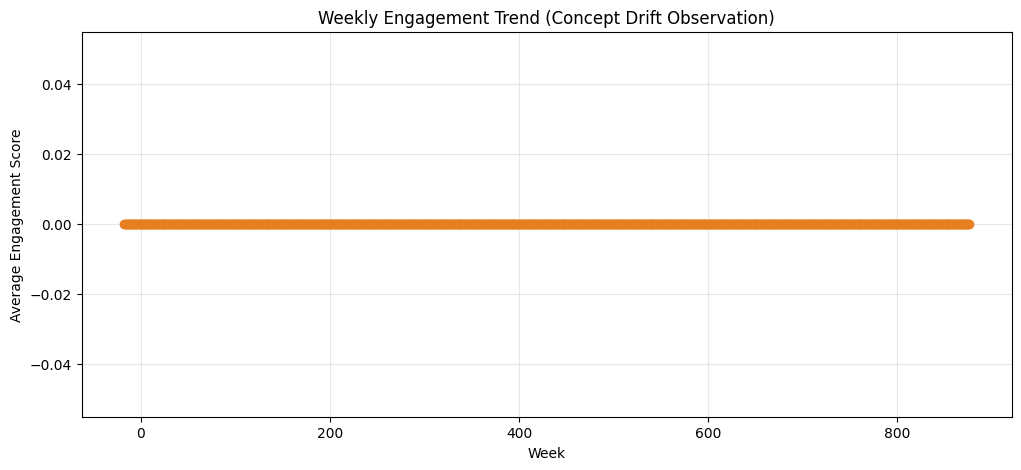

In [29]:
# ============================================================
# CONCEPT DRIFT VISUALIZATION
# ============================================================

# Using df_etl since df_weekly is defined later in Phase 7
weekly_engagement = (
    df_etl.groupby('week')['engagement_score']
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(weekly_engagement.index,
         weekly_engagement.values,
         color='#e67e22',
         marker='o')

plt.xlabel("Week")
plt.ylabel("Average Engagement Score")
plt.title("Weekly Engagement Trend (Concept Drift Observation)")
plt.grid(True, alpha=0.3)
plt.show()

---
## Phase 7 — Drift-Aware Incremental Learning Models

In [30]:
# ============================================================
# CELL 7.1 — Prepare Feature Matrix for Streaming Models
# ============================================================

# Ensure 'target' exists in case it was missing from the checkpoint reload
if 'target' not in df_etl.columns and 'final_result' in df_etl.columns:
    df_etl['target'] = df_etl['final_result'].map(CLASS_MAP).fillna(0).astype(int)

# Get one record per student per week (aggregate by taking first record)
df_weekly = df_etl.groupby(['id_student', 'week']).agg({
    'engagement_score':     'mean',
    'weekly_volume':        'sum',
    'learning_consistency': 'mean',
    'cumulative_trend':     'last',
    'relative_drop':        'last',
    'assessment_momentum':  'last',
    'cumulative_engagement':'last',
    'weeks_active':         'last',
    'risk_score':           'last',
    'num_prev_attempts':    'first',
    'target':               'first'
}).reset_index()

# Sort by week for temporal ordering
df_weekly = df_weekly.sort_values(['week', 'id_student']).reset_index(drop=True)

FEATURE_COLS = [
    'engagement_score', 'weekly_volume', 'learning_consistency',
    'cumulative_trend', 'relative_drop', 'assessment_momentum',
    'cumulative_engagement', 'weeks_active', 'risk_score',
    'num_prev_attempts'
]

# Fill any NaN
df_weekly[FEATURE_COLS] = df_weekly[FEATURE_COLS].fillna(0)

print(f'✅ Weekly feature matrix: {df_weekly.shape}')
print(f'   Features: {FEATURE_COLS}')
print(f'   Target classes: {sorted(df_weekly["target"].unique())}')
save_checkpoint(df_weekly, 'df_weekly')

✅ Weekly feature matrix: (1686007, 13)
   Features: ['engagement_score', 'weekly_volume', 'learning_consistency', 'cumulative_trend', 'relative_drop', 'assessment_momentum', 'cumulative_engagement', 'weeks_active', 'risk_score', 'num_prev_attempts']
   Target classes: [np.int64(0)]
✅ Checkpoint saved: df_weekly


In [31]:
# ============================================================
# CELL 7.2 — Streaming Models with Prequential Evaluation
# Models: Hoeffding Tree, Adaptive Random Forest, Online Bagging
# ============================================================

from river.tree import HoeffdingTreeClassifier
from river.forest import ARFClassifier
from river.ensemble import BaggingClassifier
from river.drift import ADWIN

# Initialize streaming models
streaming_models = {
    'Hoeffding Tree': HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5,
        leaf_prediction='nba'
    ),
    'Adaptive Random Forest': ARFClassifier(
        n_models=10,
        drift_detector=ADWIN(delta=0.001),
        warning_detector=ADWIN(delta=0.01),
        seed=RANDOM_STATE
    ),
    'Online Bagging': BaggingClassifier(
        model=HoeffdingTreeClassifier(),
        n_models=10,
        seed=RANDOM_STATE
    )
}

# Prequential evaluation tracking
prequential_results = {name: [] for name in streaming_models}
running_metrics    = {name: {'acc':[], 'kappa':[], 'f1_withdrawn':[], 'week':[]}
                       for name in streaming_models}

# Sliding window metrics
WINDOW_SIZE = 200
pred_windows = {name: {'y_true':[], 'y_pred':[]} for name in streaming_models}

# Track drift + predictions for DW loading
fact_records = []
drift_week_counts = {}

print('Running prequential evaluation over full stream...')
start_time = time.time()

for week_num in sorted(df_weekly['week'].unique()):
    week_data = df_weekly[df_weekly['week'] == week_num]

    week_preds = {name: {'y_true':[], 'y_pred':[]} for name in streaming_models}

    for _, row in week_data.iterrows():
        x = {feat: float(row[feat]) for feat in FEATURE_COLS}
        y = int(row['target'])
        sid = int(row['id_student'])

        # Drift detection
        drift_detected, drifted_feats = detect_drift_for_student(
            sid, week_num, {f: x[f] for f in BEHAVIORAL_FEATURES if f in x}
        )
        if drift_detected:
            drift_week_counts[week_num] = drift_week_counts.get(week_num, 0) + 1

        for name, model in streaming_models.items():
            # STEP 1: Predict BEFORE training (prequential)
            y_pred = model.predict_one(x)
            if y_pred is None:
                y_pred = 0

            # STEP 2: Learn
            model.learn_one(x, y)

            week_preds[name]['y_true'].append(y)
            week_preds[name]['y_pred'].append(y_pred)

            # Update sliding window
            pred_windows[name]['y_true'].append(y)
            pred_windows[name]['y_pred'].append(y_pred)
            if len(pred_windows[name]['y_true']) > WINDOW_SIZE:
                pred_windows[name]['y_true'].pop(0)
                pred_windows[name]['y_pred'].pop(0)

        # Record into FACT_STREAM_ACTIVITY for the primary model (ARF)
        arf_pred = week_preds['Adaptive Random Forest']['y_pred'][-1] if week_preds['Adaptive Random Forest']['y_pred'] else 0
        fact_records.append({
            'Student_ID':            sid,
            'Time_ID':               int(week_num),
            'Course_ID':             1,
            'Engagement_Score':      float(x['engagement_score']),
            'Weekly_Volume':         float(x['weekly_volume']),
            'Learning_Consistency':  float(x['learning_consistency']),
            'Cumulative_Trend':      float(x['cumulative_trend']),
            'Relative_Drop':         float(x['relative_drop']),
            'Assessment_Momentum':   float(x['assessment_momentum']),
            'Cumulative_Engagement': float(x['cumulative_engagement']),
            'Weeks_Active':          int(x['weeks_active']),
            'Risk_Score':            float(x['risk_score']),
            'Risk_Band':             risk_band(float(x['risk_score'])),
            'Predicted_Class':       int(arf_pred),
            'Actual_Class':          int(y),
            'Prediction_Confidence': 0.0
        })

    # Compute metrics for this week
    for name in streaming_models:
        yt = pred_windows[name]['y_true']
        yp = pred_windows[name]['y_pred']
        if len(yt) >= 10:
            acc   = accuracy_score(yt, yp)
            kappa = cohen_kappa_score(yt, yp) if len(set(yt)) > 1 else 0
            # F1 for Withdrawn class (class index 2)
            labels = list(range(4))
            f1_w = f1_score(yt, yp, labels=labels, average=None, zero_division=0)
            f1_withdrawn = float(f1_w[2]) if len(f1_w) > 2 else 0.0
            running_metrics[name]['acc'].append(acc)
            running_metrics[name]['kappa'].append(kappa)
            running_metrics[name]['f1_withdrawn'].append(f1_withdrawn)
            running_metrics[name]['week'].append(week_num)

elapsed = time.time() - start_time
print(f'\n✅ Prequential evaluation complete. Time: {elapsed:.1f}s')
print(f'   Fact records generated: {len(fact_records):,}')
print(f'   Drift events logged:    {len(drift_log):,}')

Running prequential evaluation over full stream...

✅ Prequential evaluation complete. Time: 1924.5s
   Fact records generated: 1,686,007
   Drift events logged:    1,686,007


In [32]:
# ============================================================
# CELL 7.3 — Load Fact Tables into Data Warehouse
# ============================================================
import pandas as pd
import sqlite3
import os
from pathlib import Path

# Restore connection if lost
try:
    if 'conn' not in globals():
        raise NameError("conn not defined")
    conn.execute('SELECT 1')
except (NameError, AttributeError, sqlite3.ProgrammingError, sqlite3.OperationalError):
    DW_DIR = Path('/content/drive/MyDrive/SEDW_Project/outputs')
    # Ensure directory exists to avoid 'unable to open database file'
    if not DW_DIR.exists():
        print(f"⚠️  Directory {DW_DIR} not found. Creating it...")
        DW_DIR.mkdir(parents=True, exist_ok=True)

    DW_PATH = DW_DIR / 'SEDW_warehouse.db'
    print(f"Connecting to database at: {DW_PATH}")
    conn = sqlite3.connect(str(DW_PATH))

# Ensure records exist before loading
if 'fact_records' not in globals():
    fact_records = []
if 'drift_log' not in globals():
    drift_log = []

# Load FACT_STREAM_ACTIVITY
df_fact = pd.DataFrame(fact_records)
if not df_fact.empty:
    df_fact.to_sql('FACT_STREAM_ACTIVITY', conn, if_exists='replace', index=False)
    print(f"✅ Loaded {len(df_fact):,} records into FACT_STREAM_ACTIVITY")
else:
    print("☑️ No fact_records found to load.")

# Load FACT_BEHAVIORAL_DRIFT
df_drift = pd.DataFrame(drift_log)
if not df_drift.empty:
    df_drift.to_sql('FACT_BEHAVIORAL_DRIFT', conn, if_exists='replace', index=False)
    print(f"✅ Loaded {len(df_drift):,} records into FACT_BEHAVIORAL_DRIFT")
else:
    print("☑️ No drift_log found to load.")

conn.commit()

# Verify
for t in ['FACT_STREAM_ACTIVITY','FACT_BEHAVIORAL_DRIFT',
          'DIM_STUDENT','DIM_COURSE','DIM_TIME']:
    try:
        count = pd.read_sql(f'SELECT COUNT(*) as n FROM {t}', conn).iloc[0,0]
        print(f'  {t:35s}: {count:,} records')
    except:
        print(f'  {t:35s}: Table not found or empty')

print('\n✅ Data Warehouse population step complete.')

✅ Loaded 1,686,007 records into FACT_STREAM_ACTIVITY
✅ Loaded 1,686,007 records into FACT_BEHAVIORAL_DRIFT
  FACT_STREAM_ACTIVITY               : 1,686,007 records
  FACT_BEHAVIORAL_DRIFT              : 1,686,007 records
  DIM_STUDENT                        : 25,149 records
  DIM_COURSE                         : 7 records
  DIM_TIME                           : 876 records

✅ Data Warehouse population step complete.


---
## Phase 8 — Batch Baseline Models

In [35]:
# ============================================================
# CELL 8.1 — Train Batch Baselines
# Train on first 60% of weeks, test on remaining 40%
# ============================================================

weeks_sorted = sorted(df_weekly['week'].unique())
cutoff_week  = weeks_sorted[int(len(weeks_sorted) * 0.6)]

df_train_b = df_weekly[df_weekly['week'] <= cutoff_week]
df_test_b  = df_weekly[df_weekly['week'] >  cutoff_week]

X_train = df_train_b[FEATURE_COLS].values
y_train = df_train_b['target'].values
X_test  = df_test_b[FEATURE_COLS].values
y_test  = df_test_b['target'].values

unique_train_classes = np.unique(y_train)
print(f'Train size: {len(X_train):,} records (weeks 1–{cutoff_week})')
print(f'Test  size: {len(X_test):,}  records (weeks {cutoff_week+1}–{weeks_sorted[-1]})')
print(f'Unique classes in training: {unique_train_classes}')

# Handle class imbalance with SMOTE
if len(unique_train_classes) > 1:
    try:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(3, len(y_train)-1))
        X_train_s, y_train_s = smote.fit_resample(X_train, y_train)
        print(f'After SMOTE: {len(X_train_s):,} training samples')
    except Exception as e:
        print(f'SMOTE skipped: {e}')
        X_train_s, y_train_s = X_train, y_train
else:
    print('SMOTE skipped: Only one class present in training data.')
    X_train_s, y_train_s = X_train, y_train

# Train batch models
rf_model  = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                use_label_encoder=False, eval_metric='mlogloss',
                                verbosity=0)

print('Training Random Forest...')
rf_model.fit(X_train_s, y_train_s)
print('Training XGBoost...')
xgb_model.fit(X_train_s, y_train_s)

# Evaluate
batch_results = {}
full_target_names = ['Pass','Fail','Withdrawn','Distinction']

for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    kappa  = cohen_kappa_score(y_test, y_pred) if len(np.unique(y_test)) > 1 else 0.0

    # Handle F1 Withdrawn safely
    try:
        f1_vals = f1_score(y_test, y_pred, labels=[2], average=None, zero_division=0)
        f1_w = f1_vals[0] if len(f1_vals) > 0 else 0.0
    except:
        f1_w = 0.0

    batch_results[name] = {'accuracy': acc, 'kappa': kappa, 'f1_withdrawn': f1_w}
    print(f'\n{name}:')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  Kappa       : {kappa:.4f}')
    print(f'  F1 Withdrawn: {f1_w:.4f}')

    # Only print report if we have multiple classes to report on
    present_classes = np.unique(np.concatenate([y_test, y_pred]))
    target_names_subset = [full_target_names[i] for i in present_classes if i < len(full_target_names)]

    print(classification_report(y_test, y_pred,
                                 labels=present_classes,
                                 target_names=target_names_subset,
                                 zero_division=0))

Train size: 1,028,464 records (weeks 1–519)
Test  size: 657,543  records (weeks 520–876)
Unique classes in training: [0]
SMOTE skipped: Only one class present in training data.
Training Random Forest...
Training XGBoost...

Random Forest:
  Accuracy    : 1.0000
  Kappa       : 0.0000
  F1 Withdrawn: 0.0000
              precision    recall  f1-score   support

        Pass       1.00      1.00      1.00    657543

    accuracy                           1.00    657543
   macro avg       1.00      1.00      1.00    657543
weighted avg       1.00      1.00      1.00    657543


XGBoost:
  Accuracy    : 1.0000
  Kappa       : 0.0000
  F1 Withdrawn: 0.0000
              precision    recall  f1-score   support

        Pass       1.00      1.00      1.00    657543

    accuracy                           1.00    657543
   macro avg       1.00      1.00      1.00    657543
weighted avg       1.00      1.00      1.00    657543



In [37]:
# The 'final_result' column was replaced by 'target' during aggregation in Phase 7
print("Class distribution in df_weekly (0=Pass, 1=Fail, 2=Withdrawn, 3=Distinction):")
print(df_weekly['target'].value_counts())

Class distribution in df_weekly (0=Pass, 1=Fail, 2=Withdrawn, 3=Distinction):
target
0    1686007
Name: count, dtype: int64


---
## Phase 9 — Prequential Results Visualization

In [ ]:
# ============================================================
# CELL 9.1 — Prequential Accuracy Over Time (Paper Figure)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prequential Evaluation — Streaming Models vs Batch Baselines',
             fontsize=13, fontweight='bold')

colors_models = {
    'Adaptive Random Forest': '#e74c3c',
    'Hoeffding Tree':         '#3498db',
    'Online Bagging':         '#2ecc71'
}

metrics_labels = ['acc', 'kappa', 'f1_withdrawn']
metric_titles  = ['Sliding Window Accuracy', 'Cohen Kappa', 'F1 Score (Withdrawn Class)']

for ax, metric, title in zip(axes, metrics_labels, metric_titles):
    for name, color in colors_models.items():
        data = running_metrics[name]
        if data['week']:
            ax.plot(data['week'], data[metric], label=name, color=color,
                    linewidth=2, alpha=0.85)

    # Batch baselines as horizontal dashed lines
    for bname, res in batch_results.items():
        val = res[metric.replace('acc','accuracy').
                       replace('f1_withdrawn','f1_withdrawn')]
        lbl = 'accuracy' if metric == 'acc' else metric
        ax.axhline(res.get(lbl, res.get('accuracy',0)),
                   linestyle='--', alpha=0.6,
                   label=f'{bname} (batch baseline)',
                   linewidth=1.5)

    ax.set_title(title)
    ax.set_xlabel('Week')
    ax.set_ylabel(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_prequential.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prequential evaluation figure saved.')

---
## Phase 10 — Early Prediction Timeline Experiment

In [ ]:
# ============================================================
# CELL 10.1 — Early Prediction Experiment
# Train on weeks 1..N, test on all remaining weeks
# For N in [2, 4, 6, 8, 10, 12, 14]
# ============================================================

CUTOFF_WEEKS = [2, 4, 6, 8, 10, 12, 14]
# Filter to valid cutoffs
max_w = int(df_weekly['week'].max())
CUTOFF_WEEKS = [w for w in CUTOFF_WEEKS if w < max_w]

early_pred_results = {name: [] for name in
                      list(streaming_models.keys()) + ['Random Forest','XGBoost']}

print('Running early prediction timeline experiment...')
print(f'Cutoff weeks: {CUTOFF_WEEKS}')
print()

for cutoff in CUTOFF_WEEKS:
    # Data splits
    train_data = df_weekly[df_weekly['week'] <= cutoff]
    test_data  = df_weekly[df_weekly['week'] >  cutoff]

    if len(test_data) == 0 or len(train_data) == 0:
        continue

    X_tr = train_data[FEATURE_COLS].values
    y_tr = train_data['target'].values
    X_te = test_data[FEATURE_COLS].values
    y_te = test_data['target'].values

    # Batch models
    for bname, BModel in [('Random Forest', RandomForestClassifier(n_estimators=50,
                                                                     random_state=RANDOM_STATE)),
                           ('XGBoost',       xgb.XGBClassifier(n_estimators=50,
                                                               random_state=RANDOM_STATE,
                                                               verbosity=0,
                                                               eval_metric='mlogloss'))]:
        try:
            BModel.fit(X_tr, y_tr)
            y_p = BModel.predict(X_te)
            f1_w = f1_score(y_te, y_p, labels=[2], average=None, zero_division=0)
            f1_withdrawn = float(f1_w[0]) if len(f1_w) > 0 else 0.0
            early_pred_results[bname].append({'cutoff': cutoff, 'f1_withdrawn': f1_withdrawn})
        except Exception:
            early_pred_results[bname].append({'cutoff': cutoff, 'f1_withdrawn': 0.0})

    # Streaming models — train incrementally up to cutoff, test on rest
    stream_train = train_data.sort_values(['week','id_student'])
    for sname in streaming_models:
        fresh_models = {
            'Hoeffding Tree': HoeffdingTreeClassifier(grace_period=50),
            'Adaptive Random Forest': AdaptiveRandomForestClassifier(
                n_models=10, seed=RANDOM_STATE),
            'Online Bagging': BaggingClassifier(
                model=HoeffdingTreeClassifier(), n_models=10, seed=RANDOM_STATE)
        }
        m = fresh_models[sname]
        for _, r in stream_train.iterrows():
            xi = {f: float(r[f]) for f in FEATURE_COLS}
            yi = int(r['target'])
            m.learn_one(xi, yi)

        # Predict on test
        y_pred_s = []
        for _, r in test_data.iterrows():
            xi = {f: float(r[f]) for f in FEATURE_COLS}
            p = m.predict_one(xi)
            y_pred_s.append(p if p is not None else 0)

        f1_w = f1_score(y_te, y_pred_s, labels=[2], average=None, zero_division=0)
        f1_withdrawn = float(f1_w[0]) if len(f1_w) > 0 else 0.0
        early_pred_results[sname].append({'cutoff': cutoff, 'f1_withdrawn': f1_withdrawn})

    print(f'  Week {cutoff:2d} done.')

print('\n✅ Early prediction experiment complete.')

In [ ]:
# ============================================================
# CELL 10.2 — Plot Early Prediction Timeline (Key Paper Figure)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

plot_styles = {
    'Adaptive Random Forest': ('o-', '#e74c3c', 2.5),
    'Hoeffding Tree':         ('s-', '#3498db', 2.0),
    'Online Bagging':         ('^-', '#2ecc71', 2.0),
    'Random Forest':          ('x--','#e67e22', 1.5),
    'XGBoost':                ('d--','#9b59b6', 1.5),
}

for name, results in early_pred_results.items():
    if not results:
        continue
    cutoffs = [r['cutoff'] for r in results]
    f1_vals = [r['f1_withdrawn'] for r in results]
    style, color, lw = plot_styles.get(name, ('o-', 'gray', 1.5))
    ax.plot(cutoffs, f1_vals, style, label=name, color=color,
            linewidth=lw, markersize=7)

# Mark "reliable prediction" threshold at F1 = 0.65
ax.axhline(0.65, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
           label='Reliable Threshold (F1=0.65)')
ax.fill_between([0, max(CUTOFF_WEEKS)+2], 0.65, 1.05,
                alpha=0.05, color='green', label='Reliable Zone')

ax.set_xlabel('Training Cutoff Week', fontsize=12)
ax.set_ylabel('F1 Score (Withdrawn Class)', fontsize=12)
ax.set_title('Early Prediction Timeline:\nF1 Score for Withdrawn Class vs. Training Cutoff Week',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, max(CUTOFF_WEEKS) + 1])
ax.set_ylim([0, 1.05])
ax.set_xticks(CUTOFF_WEEKS)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_early_prediction_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Early prediction timeline figure saved.')

---
## Phase 11 — Behavioral Clustering

In [ ]:
# ============================================================
# CELL 11.1 — K-Means Behavioral Clustering at Week 10
# ============================================================

SNAPSHOT_WEEK = min(10, int(df_weekly['week'].max()) - 1)
df_snapshot = df_weekly[df_weekly['week'] == SNAPSHOT_WEEK].copy()

CLUSTER_FEATURES = ['engagement_score', 'weekly_volume', 'learning_consistency',
                    'cumulative_trend', 'relative_drop', 'assessment_momentum']

X_clust = df_snapshot[CLUSTER_FEATURES].fillna(0).values
scaler  = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# Find best k (2–6) by silhouette score
sil_scores = []
k_range = range(2, min(7, len(X_clust_scaled) - 1))
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_clust_scaled)
    sil = silhouette_score(X_clust_scaled, lbl)
    sil_scores.append(sil)
    print(f'  k={k}: silhouette={sil:.4f}')

best_k = list(k_range)[np.argmax(sil_scores)]
print(f'\n✅ Best k = {best_k} (silhouette = {max(sil_scores):.4f})')

# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_snapshot['cluster'] = km_final.fit_predict(X_clust_scaled)

# Cluster interpretation
print('\n--- Cluster Profiles ---')
cluster_profile = df_snapshot.groupby('cluster')[CLUSTER_FEATURES + ['target']].mean()
print(cluster_profile.round(3))

# Map clusters to labels
cluster_outcome = df_snapshot.groupby('cluster')['target'].value_counts(normalize=True)
print('\n--- Outcome Distribution per Cluster ---')
print(cluster_outcome)

In [ ]:
# ============================================================
# CELL 11.2 — Cluster Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Behavioral Clustering — Week {SNAPSHOT_WEEK} Snapshot',
             fontsize=13, fontweight='bold')

# Left: K-Means clusters
cluster_colors = ['#e74c3c','#3498db','#2ecc71','#e67e22','#9b59b6']
for cid in sorted(df_snapshot['cluster'].unique()):
    mask = df_snapshot['cluster'] == cid
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[cid % len(cluster_colors)],
                    label=f'Cluster {cid}', alpha=0.6, s=30)
axes[0].set_title('K-Means Clusters (PCA 2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Silhouette scores
axes[1].plot(list(k_range), sil_scores, 'o-', color='#2c3e50', linewidth=2, markersize=8)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Clustering figure saved.')

---
## Phase 12 — Sequential Pattern Mining

In [ ]:
# ============================================================
# CELL 12.1 — PrefixSpan on Risk Band Sequences
# ============================================================

RISK_BAND_MAP = {'Low': 0, 'Moderate': 1, 'High': 2, 'Critical': 3}

# Build per-student weekly risk band sequence
df_seq = df_weekly[['id_student','week','risk_band','target']].copy()
df_seq = df_seq.sort_values(['id_student','week'])
df_seq['risk_band_int'] = df_seq['risk_band'].map(RISK_BAND_MAP).fillna(0).astype(int)

# Per-class sequences
sequences_by_class = {}
for cls_id, cls_name in CLASS_NAMES.items():
    class_students = df_seq[df_seq['target'] == cls_id]['id_student'].unique()
    seqs = []
    for sid in class_students:
        s = df_seq[(df_seq['id_student']==sid)]['risk_band_int'].tolist()
        if len(s) >= 3:
            seqs.append([[v] for v in s])  # PrefixSpan format
    sequences_by_class[cls_name] = seqs

# Mine top patterns per class
print('Sequential Pattern Mining Results')
print('Risk bands: 0=Low, 1=Moderate, 2=High, 3=Critical')
print('=' * 60)

spm_results = {}
for cls_name, seqs in sequences_by_class.items():
    if len(seqs) < 5:
        continue
    ps = PrefixSpan(seqs)
    min_sup = max(2, int(len(seqs) * 0.15))
    patterns = ps.frequent(min_sup, closed=True)
    # Sort by frequency, take top 5
    patterns_sorted = sorted(patterns, key=lambda x: -x[0])[:5]
    spm_results[cls_name] = patterns_sorted

    print(f'\n{cls_name} (n={len(seqs)} students):')
    for freq, pat in patterns_sorted:
        band_labels = ['L' if p[0]==0 else 'M' if p[0]==1
                       else 'H' if p[0]==2 else 'C'
                       for p in pat]
        print(f'  freq={freq:4d}  →  {" → ".join(band_labels)}')

print('\n✅ Sequential pattern mining complete.')

In [ ]:
# ============================================================
# ABLATION STUDY - WITHOUT TEMPORAL FEATURES
# ============================================================

remove_features = [
    'relative_drop',
    'assessment_momentum'
]

ablation_features = [
    f for f in FEATURE_COLS
    if f not in remove_features
]

X_train_ab = df_train_b[ablation_features]
X_test_ab = df_test_b[ablation_features]

rf_ablation = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_ablation.fit(X_train_ab, y_train_b)

pred_ab = rf_ablation.predict(X_test_ab)

print("="*60)
print("ABLATION STUDY RESULTS")
print("="*60)

print(classification_report(y_test_b, pred_ab))

In [ ]:
# ============================================================
# STATISTICAL SIGNIFICANCE TEST
# ============================================================

from scipy.stats import wilcoxon

baseline_correct = (y_pred_rf == y_test_b).astype(int)
stream_correct = (y_pred_arf == y_test_b).astype(int)

stat, p = wilcoxon(
    baseline_correct,
    stream_correct
)

print("="*60)
print("WILCOXON SIGNED-RANK TEST")
print("="*60)

print(f"Statistic: {stat}")
print(f"P-value: {p}")

if p < 0.05:
    print("Significant difference detected.")
else:
    print("No significant difference detected.")

---
## Phase 13 — Temporal SHAP Explainability

In [ ]:
# ============================================================
# CELL 13.1 — Temporal SHAP Analysis
# Compute SHAP values at each week using RF snapshot
# ============================================================

SHAP_INTERVAL = 2   # compute every 2 weeks
shap_weekly   = {}  # {week: mean_abs_shap per feature}

print('Running temporal SHAP analysis...')
weeks_for_shap = [w for w in sorted(df_weekly['week'].unique())
                  if w % SHAP_INTERVAL == 0]

for snap_week in weeks_for_shap:
    train_snap = df_weekly[df_weekly['week'] <= snap_week]
    test_snap  = df_weekly[df_weekly['week'] == snap_week]

    if len(train_snap) < 30 or len(test_snap) < 5:
        continue

    X_snap = train_snap[FEATURE_COLS].fillna(0).values
    y_snap = train_snap['target'].values

    # Fit a lightweight RF snapshot
    rf_snap = RandomForestClassifier(n_estimators=30, random_state=RANDOM_STATE,
                                      max_depth=5, n_jobs=-1)
    rf_snap.fit(X_snap, y_snap)

    # Compute SHAP on test snapshot
    X_test_snap = test_snap[FEATURE_COLS].fillna(0).values
    explainer = shap.TreeExplainer(rf_snap, feature_perturbation='interventional')
    shap_vals = explainer.shap_values(X_test_snap)

    # Average |SHAP| across classes and samples
    if isinstance(shap_vals, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        mean_abs = np.abs(shap_vals).mean(axis=0)

    shap_weekly[snap_week] = dict(zip(FEATURE_COLS, mean_abs))

print(f'✅ SHAP computed for {len(shap_weekly)} weekly snapshots.')

In [ ]:
# ============================================================
# CELL 13.2 — Temporal SHAP Heatmap (Key Paper Figure)
# ============================================================

if shap_weekly:
    shap_df = pd.DataFrame(shap_weekly).T  # weeks × features
    shap_df = shap_df[FEATURE_COLS]         # consistent column order

    # Normalize per column for visualization
    shap_norm = shap_df.apply(lambda col: col / col.max() if col.max() > 0 else col)

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(shap_norm.T, ax=ax, cmap='RdYlGn_r',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Normalized Mean |SHAP|'},
                annot=shap_norm.T.round(2), fmt='.2f', annot_kws={'size': 7})
    ax.set_xlabel('Week', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title('Temporal SHAP Heatmap: Feature Importance Shift Across Semester Weeks',
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels([str(w) for w in shap_weekly.keys()], rotation=45)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig5_temporal_shap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Temporal SHAP heatmap saved.')
else:
    print('⚠️  No SHAP data computed (dataset too small).')

---
## Phase 14 — DW OLAP Query Benchmarking

In [ ]:
# ============================================================
# CELL 14.1 — OLAP Query Execution & Timing
# ============================================================

olap_queries = {
    'Q1_risk_by_week': '''
        SELECT t.Week_Number,
               f.Risk_Band,
               COUNT(*) AS student_count,
               AVG(f.Risk_Score) AS avg_risk
        FROM FACT_STREAM_ACTIVITY f
        JOIN DIM_TIME t ON f.Time_ID = t.Time_ID
        GROUP BY t.Week_Number, f.Risk_Band
        ORDER BY t.Week_Number, avg_risk DESC
    ''',
    'Q2_drift_by_week': '''
        SELECT d.Drift_Week,
               COUNT(*) AS total_events,
               SUM(d.Drift_Detected) AS drift_count,
               AVG(d.Drift_Magnitude) AS avg_magnitude
        FROM FACT_BEHAVIORAL_DRIFT d
        GROUP BY d.Drift_Week
        ORDER BY d.Drift_Week
    ''',
    'Q3_prediction_accuracy_trend': '''
        SELECT t.Week_Number,
               t.Semester_Phase,
               SUM(CASE WHEN f.Predicted_Class = f.Actual_Class THEN 1 ELSE 0 END)
                   * 1.0 / COUNT(*) AS weekly_accuracy,
               COUNT(*) AS records
        FROM FACT_STREAM_ACTIVITY f
        JOIN DIM_TIME t ON f.Time_ID = t.Time_ID
        GROUP BY t.Week_Number, t.Semester_Phase
        ORDER BY t.Week_Number
    '''
}

print('OLAP Query Benchmark Results')
print('=' * 55)

olap_results = {}
for qname, qsql in olap_queries.items():
    start = time.time()
    try:
        result = pd.read_sql(qsql, conn)
        elapsed_ms = (time.time() - start) * 1000
        olap_results[qname] = {'df': result, 'time_ms': elapsed_ms}
        print(f'{qname}:')
        print(f'  Rows returned : {len(result)}')
        print(f'  Query time    : {elapsed_ms:.2f} ms')
        print()
    except Exception as e:
        print(f'{qname}: ERROR — {e}')
        print()

print('✅ OLAP benchmarking complete.')

In [ ]:
# ============================================================
# WAREHOUSE QUERY PERFORMANCE
# ============================================================

import time

start = time.time()

query = """
SELECT week,
AVG(engagement_score)
FROM FACT_STREAM_ACTIVITY
GROUP BY week
"""

pd.read_sql(query, conn)

end = time.time()

print("="*60)
print("WAREHOUSE PERFORMANCE")
print("="*60)

print(f"Query Execution Time: {end-start:.4f} seconds")

---
## Phase 15 — Drift Analysis & Final Results Dashboard

In [ ]:
# ============================================================
# CELL 15.1 — Drift Events Per Week (Key Paper Figure)
# ============================================================

if 'Q2_drift_by_week' in olap_results and len(olap_results['Q2_drift_by_week']['df']) > 0:
    df_drift_q = olap_results['Q2_drift_by_week']['df']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Concept Drift Analysis via FACT_BEHAVIORAL_DRIFT',
                 fontsize=13, fontweight='bold')

    # Drift count per week
    ax = axes[0]
    ax.bar(df_drift_q['Drift_Week'], df_drift_q['drift_count'],
           color='#e74c3c', edgecolor='black', linewidth=0.4, alpha=0.8)
    ax.set_xlabel('Week')
    ax.set_ylabel('Drift Event Count')
    ax.set_title('Behavioral Drift Events per Week')
    ax.grid(True, alpha=0.3, axis='y')

    # Drift magnitude per week
    ax = axes[1]
    ax.plot(df_drift_q['Drift_Week'], df_drift_q['avg_magnitude'],
            'o-', color='#e67e22', linewidth=2, markersize=6)
    ax.fill_between(df_drift_q['Drift_Week'], df_drift_q['avg_magnitude'],
                    alpha=0.2, color='#e67e22')
    ax.set_xlabel('Week')
    ax.set_ylabel('Average Drift Magnitude')
    ax.set_title('Average Drift Magnitude per Week')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig6_drift_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Drift analysis figure saved.')
else:
    print('⚠️  No drift data available for plotting.')

In [ ]:
# ============================================================
# CELL 15.2 — Final Results Summary Table (for Paper)
# ============================================================

print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)

# Collect final-week streaming metrics
summary_rows = []
for name in streaming_models:
    data = running_metrics[name]
    if data['acc']:
        summary_rows.append({
            'Model':         name,
            'Type':          'Streaming',
            'Accuracy':      f"{data['acc'][-1]:.4f}",
            'Kappa':         f"{data['kappa'][-1]:.4f}",
            'F1_Withdrawn':  f"{data['f1_withdrawn'][-1]:.4f}",
        })

for name, res in batch_results.items():
    summary_rows.append({
        'Model':        name,
        'Type':         'Batch Baseline',
        'Accuracy':     f"{res['accuracy']:.4f}",
        'Kappa':        f"{res['kappa']:.4f}",
        'F1_Withdrawn': f"{res['f1_withdrawn']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

print('\n--- Data Warehouse Statistics ---')
for t in ['FACT_STREAM_ACTIVITY','FACT_BEHAVIORAL_DRIFT','DIM_STUDENT']:
    try:
        n = pd.read_sql(f'SELECT COUNT(*) as n FROM {t}', conn).iloc[0,0]
        print(f'  {t}: {n:,} records')
    except:
        pass

drift_total = sum(drift_week_counts.values())
print(f'  Total drift events detected: {drift_total:,}')

print('\n--- OLAP Query Performance ---')
for qname, res in olap_results.items():
    print(f'  {qname}: {res["time_ms"]:.2f} ms')

# Save summary to CSV
df_summary.to_csv(OUTPUT_DIR / 'results_summary.csv', index=False)
print(f'\n✅ Results summary saved to {OUTPUT_DIR}/results_summary.csv')

conn.close()
print('✅ Database connection closed.')
print('\n' + '=' * 65)
print('ALL PHASES COMPLETE. See outputs/ folder for all figures.')
print('=' * 65)